# Topology Optimisation with EllPHi Gradients

This notebook demonstrates how to use `ellphi.grad` for gradient-based
optimisation of ellipsoid configurations. No dependencies beyond **ellphi**
and **scipy** are required.

**Sections**
1. Gradient-aware tangency (single pair)
2. Batch gradients and the VJP pattern
3. [Placeholder] Persistence diagram optimisation

In [1]:
import numpy as np
import ellphi
from ellphi import (
    tangency_grad,
    pdist_tangency_grad,
    pdist_tangency,
    coef_from_axes,
    coef_from_cov,
    tangency,
)

rng = np.random.default_rng(42)
print('ellphi version:', ellphi.__version__)

ellphi version: 0.1.2.dev0


---
## 1. Gradient-aware tangency (single pair)

`tangency_grad(p, q)` returns a `TangencyGrad` dataclass with three fields:

| Field | Shape | Meaning |
|-------|-------|---------|
| `t` | scalar | Tangency distance (same as `tangency(p, q).t`) |
| `dt_dp` | `(m,)` | Gradient of `t` w.r.t. first-ellipsoid coefficients |
| `dt_dq` | `(m,)` | Gradient of `t` w.r.t. second-ellipsoid coefficients |

`coef_from_axes(X, r0, r1, theta)` builds a single ellipse coefficient vector
from a center `X`, semi-axes `r0`/`r1`, and orientation angle `theta`.

In [2]:
# Build two 2-D ellipses from axes/angle representation
p = coef_from_axes(np.array([0.0, 0.0]), 3.0, 1.0, 0.3)
q = coef_from_axes(np.array([4.0, 1.0]), 2.0, 0.5, -0.5)

g = tangency_grad(p, q)
print(f't          = {g.t:.6f}')
print(f'dt_dp      = {g.dt_dp}')
print(f'dt_dq      = {g.dt_dq}')

t          = 1.042287
dt_dp      = [3.13295714 2.49616215 0.49720002 2.2102748  0.88051065 0.38983255]
dt_dq      = [0.72235141 0.57552854 0.11463711 0.50961282 0.20301526 0.08988188]


In [3]:
# Quick finite-difference check for dt_dp[0]
h = 1e-6
p_plus = p.copy()
p_plus[0] += h
p_minus = p.copy()
p_minus[0] -= h
fd = (tangency(p_plus, q).t - tangency(p_minus, q).t) / (2 * h)
print(f'analytic dt_dp[0] = {g.dt_dp[0]:.8f}')
print(f'finite-diff       = {fd:.8f}')
print(f'relative error    = {abs(g.dt_dp[0] - fd) / abs(fd):.2e}')

analytic dt_dp[0] = 3.13295714
finite-diff       = 3.13295714
relative error    = 2.69e-11


---
## 2. Batch gradients and the VJP pattern

`pdist_tangency_grad(coefs)` returns:
- `dists`: condensed pairwise distance array (same as `pdist_tangency`)
- `vjp`: a pullback `grad_dists → grad_coefs` that accumulates upstream
  gradients into per-ellipsoid coefficient gradients

The VJP can be chained with any scalar loss `L(dists)` via the chain rule:
`∂L/∂coefs = vjp(∂L/∂dists)`

In [4]:
# Build a small cloud of N=5 random 2-D ellipses
N = 5
means = rng.uniform(-20, 20, (N, 2))
covs = np.stack([
    (lambda F: F @ F.T + 4 * np.eye(2))(rng.standard_normal((2, 2)))
    for _ in range(N)
])
coefs = coef_from_cov(means, covs)

dists, vjp = pdist_tangency_grad(coefs)

# Verify distances match pdist_tangency
ref = pdist_tangency(coefs)
print('max |dists - ref|:', np.max(np.abs(dists - ref)))
print('distances:', dists)

max |dists - ref|: 0.0
distances: [2.29796195 8.07432226 3.18499214 5.91116232 7.6311246  1.21815661
 6.87865889 6.05896354 5.01377611 6.56044731]


In [5]:
# Example: gradient of sum(dists) w.r.t. all coefficients
grad_coefs = vjp(np.ones_like(dists))
print('grad_coefs shape:', grad_coefs.shape)  # (N, m)
print('grad_coefs[0]:', grad_coefs[0])

grad_coefs shape: (5, 6)
grad_coefs[0]: [29.27797444 16.4591706   5.01931062  4.31358709  1.63785166  0.26589981]


---
## 3. Persistence Diagram Optimisation via VJP (homcloud)

This section drives gradient descent on ellipsoid centres using a
**persistence-diagram loss** on H1 features computed with
[homcloud](https://homcloud.dev).

### Setup

* N = 8 two-dimensional ellipsoids with **fixed** isotropic shape
  (covariance `1.5 I`) whose centres are optimised.
* The N × N tangency-distance matrix `D` is fed to
  `hc.PDList.from_rips_filtration` to build a **flag (clique)
  filtration** on the complete weighted graph.  Because `t(P, Q)` is a
  dissimilarity (not a metric — the triangle inequality fails in
  general), the resulting persistence diagram is interpreted as the PH
  of a weighted graph, not as Vietoris–Rips PH of a metric space.

### Loss and gradient chain

A single H1 birth–death pair `(b, d)` is targeted.  The loss is

    L = (b − b*)² + (d − d*)²

where `(b*, d*)` is a feasible target with `b* < d*`.

The gradient flows through the following chain:

    ∂L/∂dists   (sparse: only the birth edge and the death edge are non-zero)
         ↓  vjp
    ∂L/∂coefs   (shape N × m)
         ↓  Jacobian of coef_from_cov w.r.t. centres
    ∂L/∂centres (shape N × 2)

For a Rips H1 pair in generic position, `b` is the weight of a unique
birth edge and `d` is the weight of a unique death-controlling edge, so
`∂b/∂dists[k]` and `∂d/∂dists[k]` are 0 or 1.  Both edges are
identified by scanning `D` (float32) for unique matches; a non-unique
match indicates a degenerate (non-smooth) step and the loop stops.

**Float32 approximation note.** HomCloud / ripser uses float32 distances
internally.  Critical edges are selected from the float32 matrix, while
the VJP pullback operates on the original float64 tangency distances.
This is a reasonable numerical approximation; strictly speaking it is
the gradient of the ideal real-weight filtration value, not of the
exact float32-rounded pipeline.

**Smoothness note.** The map from centres to the selected pair is only
*locally* smooth.  As long as the critical edges and the selected H1
pair do not change, the update is the **ordinary gradient** of that
local smooth branch.  When ties or pairing switches occur the objective
is non-smooth; the same step acts as a heuristic continuation and offers
no convergence guarantee.

### Centre-only Jacobian

With fixed inverse covariance `Q = cov⁻¹` and centre `X`, the packed
ellphi coefficients satisfy `ℓ = −Q X` and `c = Xᵀ Q X`.  The
Jacobian `J = d(coef)/d(X)` is therefore

    J = [ 0,  0  ]   ← quad block (fixed)
        [ 0,  0  ]
        [ 0,  0  ]
        [−Q₁₁, −Q₁₂]  ← linear block
        [−Q₁₂, −Q₂₂]
        [2(QX)₁, 2(QX)₂]  ← constant

and `grad_X = Jᵀ @ grad_coef`.

In [6]:
import homcloud.interface as hc
import tempfile
import os
import matplotlib.pyplot as plt

# --- Initial configuration ---
# N ellipsoids with fixed isotropic covariance arranged roughly on a circle.
# Using a separate RNG so this section is reproducible independently.
rng_opt = np.random.default_rng(7)
N_OPT = 8
angles_opt = np.linspace(0, 2 * np.pi, N_OPT, endpoint=False)
centers_init = np.column_stack(
    [3.0 * np.cos(angles_opt), 3.0 * np.sin(angles_opt)]
) + rng_opt.normal(0, 0.2, (N_OPT, 2))

cov_shape = 1.5 * np.eye(2)
covs_opt = np.stack([cov_shape] * N_OPT)
inv_covs_opt = np.linalg.inv(covs_opt)  # Q = cov^{-1}, fixed throughout


def build_D_and_pd(centers, covs, N):
    """Compute pairwise tangency distances and the H1 persistence diagram."""
    coefs = coef_from_cov(centers, covs)
    dists, vjp = pdist_tangency_grad(coefs)
    # Build float32 distance matrix (homcloud / ripser uses float32 internally)
    D = np.zeros((N, N), dtype=np.float32)
    k = 0
    for i in range(N):
        for j in range(i + 1, N):
            D[i, j] = D[j, i] = dists[k]
            k += 1
    with tempfile.NamedTemporaryFile(suffix=".pdgm", delete=False) as f:
        tmp = f.name
    pdlist = hc.PDList.from_rips_filtration(D, maxdim=1, save_to=tmp)
    pd1 = pdlist.dth_diagram(1)
    os.unlink(tmp)
    return dists, vjp, D, pd1


# Verify initial configuration has exactly one H1 pair
_, _, D_init, pd1_init = build_D_and_pd(centers_init, covs_opt, N_OPT)
pairs_init = pd1_init.pairs()
assert len(pairs_init) == 1, (
    f"Expected exactly 1 H1 pair for the demo, got {len(pairs_init)}. "
    "Try a different initial configuration."
)
p0 = pairs_init[0]
b0, d0 = float(p0.birth), float(p0.death)
print(f"Initial H1 pair: birth = {b0:.4f}, death = {d0:.4f}, "
      f"persistence = {d0 - b0:.4f}")

Initial H1 pair: birth = 1.1027, death = 2.1507, persistence = 1.0480


In [7]:
def condensed_idx(i, j, N):
    """SciPy-style condensed index for the unordered edge {i, j}."""
    if i > j:
        i, j = j, i
    return N * i - i * (i + 1) // 2 + j - i - 1


def find_unique_edge(D_f32, val_f32, N):
    """Return the unique edge (i, j) with D_f32[i, j] == val_f32.

    The genericity assumption required for the gradient to be well-defined
    is that the birth (or death) value is attained by exactly one edge in the
    float32 distance matrix seen by homcloud / ripser.  If more than one edge
    matches, the configuration is degenerate and the caller should stop.

    Note: homcloud 4.8.0 does not expose birth/death simplex vertex indices
    for Rips filtrations (RipsResolver.resolve_cells is not implemented).
    This scan is the correct fallback under the generic-position assumption.
    """
    matches = [
        (i, j)
        for i in range(N)
        for j in range(i + 1, N)
        if D_f32[i, j] == val_f32
    ]
    return matches[0] if len(matches) == 1 else None


def center_gradient(grad_coefs, centers, inv_covs):
    """Backpropagate grad_coefs to centre coordinates.

    With fixed Q = inv_cov, the packed ellphi conic coefficients are:
      quad block  (indices 0..n_quad-1): constant, no centre dependence
      linear block (indices n_quad..n_quad+n-1): ℓ = −Q X
      constant    (index -1):              c  = Xᵀ Q X

    The Jacobian J = d(coef)/d(X) has:
      rows for quad:    0
      rows for linear: −Q   (n × n matrix)
      row  for const:  2(QX)ᵀ

    Hence grad_X = Jᵀ @ g = −Q @ g_linear + 2*(Q @ X) * g_const.

    For 2D ellipses (n=2), the packed layout is
      [Q11, Q12, Q22, l1, l2, c], so n_quad = 3.
    """
    N = len(centers)
    n = centers.shape[1]          # spatial dimension
    n_quad = n * (n + 1) // 2    # number of upper-triangular quad entries
    grad_centers = np.zeros_like(centers)
    for i in range(N):
        Q = inv_covs[i]
        X = centers[i]
        g = grad_coefs[i]
        g_linear = g[n_quad: n_quad + n]
        g_const = g[-1]
        grad_centers[i] = -Q @ g_linear + 2.0 * (Q @ X) * g_const
    return grad_centers

In [8]:
# --- Optimisation target ---
# Shrink persistence: push birth up and death down by delta,
# ensuring b* < d* (feasibility).
delta = min(0.2, 0.25 * (d0 - b0))
b_star = b0 + delta
d_star = d0 - delta
print(f"Target: b* = {b_star:.4f}, d* = {d_star:.4f}  (delta = {delta:.4f})")

# --- Gradient-descent loop ---
# On each locally smooth branch (fixed critical edges and H1 pairing)
# this is ordinary gradient descent.  When pairing switches or ties
# occur it acts as a heuristic continuation step.
lr = 0.05
n_steps = 40

centers_cur = centers_init.copy()
history = [(b0, d0)]
losses = []

for step in range(n_steps):
    dists, vjp, D, pd1 = build_D_and_pd(centers_cur, covs_opt, N_OPT)
    pairs = pd1.pairs()

    # Stop if the number of H1 pairs has changed
    if len(pairs) != 1:
        print(f"Step {step}: H1 count = {len(pairs)}, stopping.")
        break

    # Exactly one H1 pair at this point; take it directly
    p = pairs[0]
    b, d = float(p.birth), float(p.death)
    history.append((b, d))
    loss = (b - b_star) ** 2 + (d - d_star) ** 2
    losses.append(loss)

    if (step + 1) % 10 == 0 or step == 0:
        print(f"Step {step + 1:3d}: b = {b:.4f}, d = {d:.4f}, L = {loss:.6f}")

    # Identify the birth and death edges from the float32 distance matrix.
    # Under the generic-position assumption (no two edges share the same
    # float32 weight), each filtration value corresponds to a unique edge.
    # The gradient is then the exact derivative of that locally smooth branch;
    # the float64→float32 rounding in the filtration step is not back-propagated.
    birth_edge = find_unique_edge(D, np.float32(b), N_OPT)
    death_edge = find_unique_edge(D, np.float32(d), N_OPT)

    if birth_edge is None or death_edge is None:
        # Non-unique edge: degenerate (non-smooth) configuration.
        print(f"Step {step}: non-unique birth or death edge, stopping.")
        break

    # Assemble the sparse upstream gradient in distance space.
    # ∂L/∂dists is non-zero only at the two critical edges.
    grad_dists = np.zeros_like(dists)
    grad_dists[condensed_idx(*birth_edge, N_OPT)] += 2.0 * (b - b_star)
    grad_dists[condensed_idx(*death_edge, N_OPT)] += 2.0 * (d - d_star)

    # Pull back through the VJP to coefficient space, then to centre space.
    grad_coefs = vjp(grad_dists)
    grad_c = center_gradient(grad_coefs, centers_cur, inv_covs_opt)

    centers_cur = centers_cur - lr * grad_c

print(f"\nFinal H1 pair: birth = {history[-1][0]:.4f}, death = {history[-1][1]:.4f}")
print(f"Target:        b*    = {b_star:.4f},  d*    = {d_star:.4f}")

Target: b* = 1.3027, d* = 1.9507  (delta = 0.2000)
Step   1: b = 1.1027, d = 2.1507, L = 0.080000
Step  10: b = 1.1553, d = 2.1065, L = 0.045975


Step  20: b = 1.1977, d = 2.0748, L = 0.026426
Step  30: b = 1.2279, d = 2.0497, L = 0.015384
Step  40: b = 1.2494, d = 2.0296, L = 0.009065

Final H1 pair: birth = 1.2494, death = 2.0296
Target:        b*    = 1.3027,  d*    = 1.9507


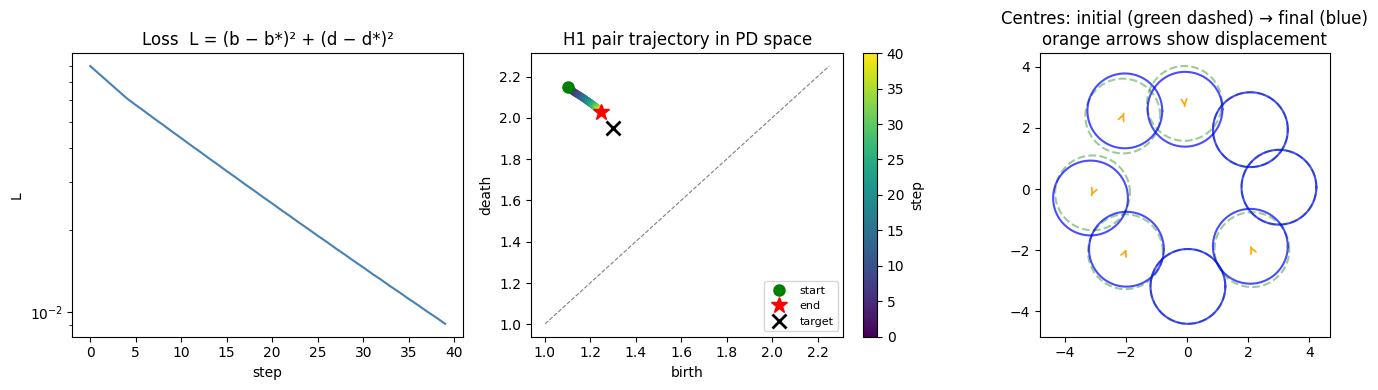

In [9]:
history = np.array(history)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# --- Panel 1: loss curve ---
ax = axes[0]
ax.plot(losses, color="steelblue")
ax.set_xlabel("step")
ax.set_ylabel("L")
ax.set_title("Loss  L = (b − b*)² + (d − d*)²")
ax.set_yscale("log")

# --- Panel 2: H1 pair trajectory in PD space ---
ax = axes[1]
diag_lo = min(history[:, 0].min(), b_star, d_star) - 0.1
diag_hi = max(history[:, 1].max(), b_star, d_star) + 0.1
ax.plot([diag_lo, diag_hi], [diag_lo, diag_hi], "gray", lw=0.8, ls="--")

sc = ax.scatter(
    history[:, 0], history[:, 1],
    c=np.arange(len(history)), cmap="viridis",
    s=20, zorder=3,
)
ax.plot(history[0, 0], history[0, 1], "go", ms=8, label="start", zorder=4)
ax.plot(history[-1, 0], history[-1, 1], "r*", ms=12, label="end", zorder=4)
ax.plot(b_star, d_star, "kx", ms=10, mew=2, label="target", zorder=5)
plt.colorbar(sc, ax=ax, label="step")
ax.set_xlabel("birth")
ax.set_ylabel("death")
ax.set_title("H1 pair trajectory in PD space")
ax.legend(fontsize=8)

# --- Panel 3: initial vs final ellipsoid centres ---
ax = axes[2]
r_ell = np.sqrt(cov_shape[0, 0])   # radius of isotropic ellipsoid
theta_ell = np.linspace(0, 2 * np.pi, 60)
cos_t, sin_t = np.cos(theta_ell), np.sin(theta_ell)
for i in range(N_OPT):
    ci = centers_init[i]
    cf = centers_cur[i]
    ax.plot(ci[0] + r_ell * cos_t, ci[1] + r_ell * sin_t, "g--", alpha=0.4)
    ax.plot(cf[0] + r_ell * cos_t, cf[1] + r_ell * sin_t, "b-", alpha=0.7)
    ax.annotate("", xy=cf, xytext=ci,
                arrowprops=dict(arrowstyle="->", color="orange", lw=1.2))
ax.set_aspect("equal")
ax.set_title("Centres: initial (green dashed) → final (blue)\norange arrows show displacement")

plt.tight_layout()
plt.show()